### Loading Processed Data

In [24]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("X_train_prepared.csv", index_col=0)
y_train = pd.read_csv("y_train_prepared.csv", index_col=0).squeeze()

X_test  = pd.read_csv("X_test_processed.csv", index_col=0)
y_test  = pd.read_csv("y_test.csv", index_col=0).squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (747, 18)
X_test : (195, 18)


### Baseline KNN with k=5

In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Baseline KNN (k=5)")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

Baseline KNN (k=5)
MAE  : 94.65
RMSE : 121.77
R²   : 0.8223


### Fiding the best k for the prediction

In [27]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

k_range = range(1, 31)
rmse_scores = []

for k in k_range:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse_scores.append(-scores.mean())

best_k = list(k_range)[np.argmin(rmse_scores)]
print(f"Best k: {best_k}  (CV-RMSE = {min(rmse_scores):.2f})")

Best k: 10  (CV-RMSE = 112.33)


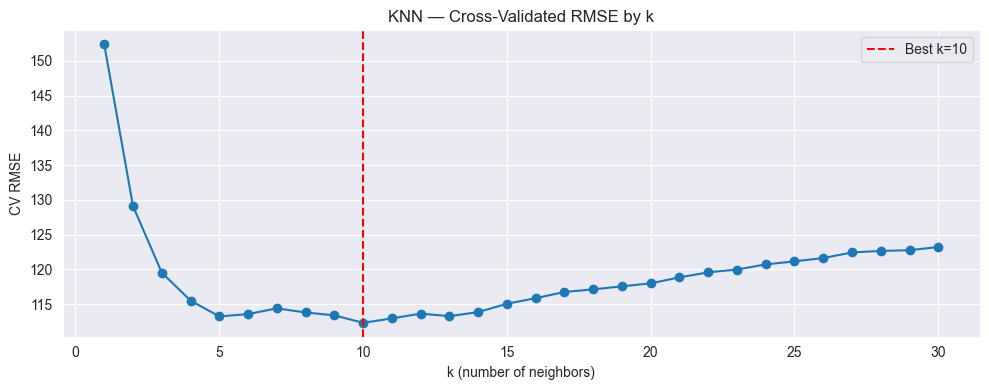

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_range), rmse_scores, marker="o", linewidth=1.5)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("CV RMSE")
plt.title("KNN — Cross-Validated RMSE by k")
plt.legend()
plt.tight_layout()
plt.show()

### Applying KNN after finding the best k (k=10)

In [29]:
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print(f"Best KNN (k={best_k})")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")

Best KNN (k=10)
MAE  : 95.76
RMSE : 119.74
R²   : 0.8281


The MAE is high in our context and the r2 = 0.82 is not a good score (under 0.90). 

### Predicted vs Actual Plot

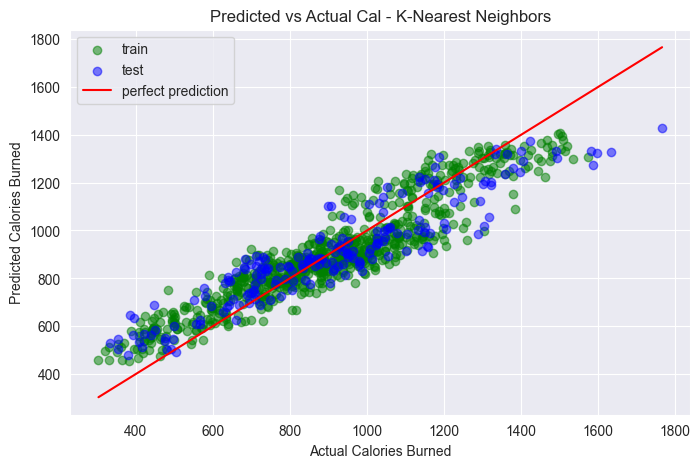

In [20]:
import matplotlib.pyplot as plt


y_pred_train_best = knn_best.predict(X_train)


plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_pred_train_best, c='green', label='train', alpha=0.5)

plt.scatter(y_test, y_pred_best, c='blue', label='test', alpha=0.5)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.legend()
plt.title('Predicted vs Actual Cal - K-Nearest Neighbors')

plt.show()

We can notice from this figure that when it comes to predicting lower amount of calories our model overestimates, but for larger it underestimates. 

### Residual Distribution

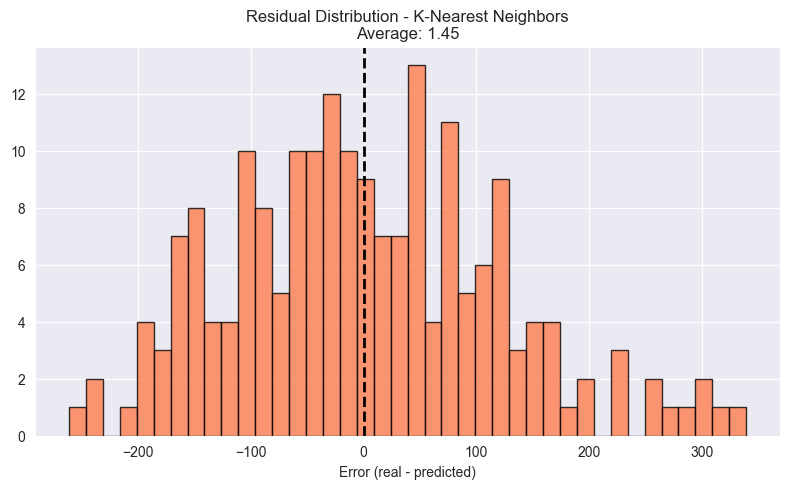

In [21]:
import matplotlib.pyplot as plt

residuals_knn = y_test.values - y_pred_best

plt.figure(figsize=(8, 5))

plt.hist(residuals_knn, bins=40, color='coral', edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linestyle='--', lw=2)

plt.xlabel("Error (real - predicted)")
plt.title(f"Residual Distribution - K-Nearest Neighbors\nAverage: {residuals_knn.mean():.2f}")
plt.tight_layout()
plt.show()

The average is low so this histogram confirms our statement from the previous figure.  

### Feature Importance 

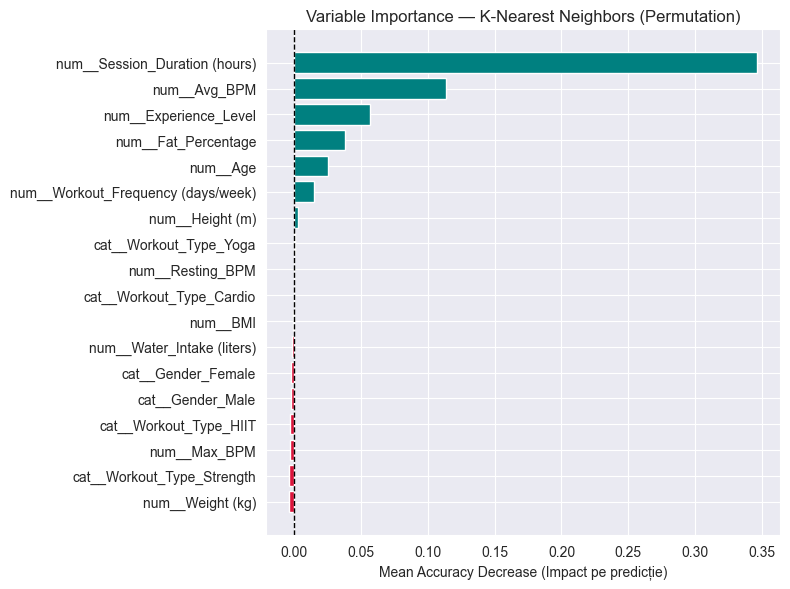

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

result = permutation_importance(knn_best, X_train, y_train, n_repeats=10, random_state=42)
importance_knn = result.importances_mean

feat_df_knn = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_knn
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))

colors_knn = ['crimson' if x < 0 else 'teal' for x in feat_df_knn['Importance']]
plt.barh(feat_df_knn['Feature'], feat_df_knn['Importance'], color=colors_knn)

plt.title("Variable Importance — K-Nearest Neighbors (Permutation)")
plt.xlabel("Mean Accuracy Decrease (Impact pe predicție)")
plt.axvline(0, color='black', linestyle='--', lw=1) 

plt.tight_layout()
plt.show()

The features at the very bottom have a slightly bad impact for our model because KNN relies on calculating the mathematical distance, so irrelevant features confuse tha algorithm. 

### Learning Curve 

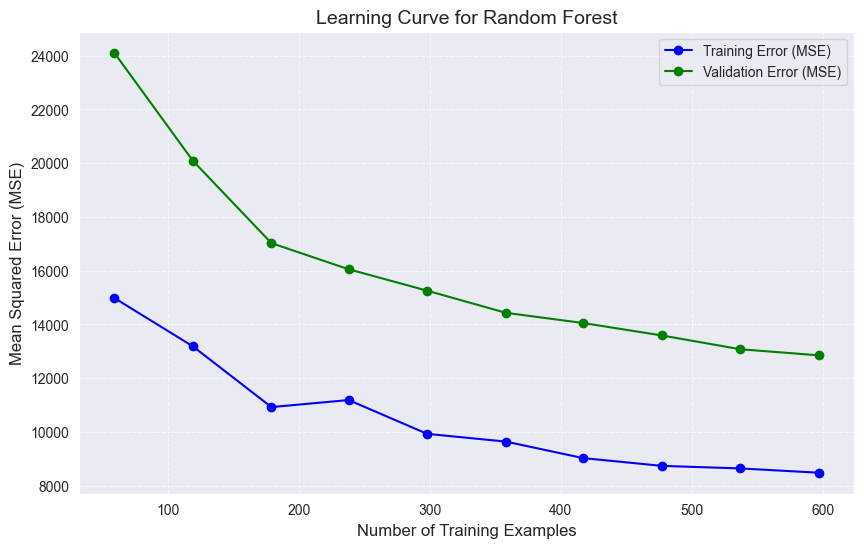

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calculate scores for the learning curve using rf_model
train_sizes, train_scores, test_scores = learning_curve(
    knn, 
    X_train, 
    y_train, 
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using MSE
    train_sizes=np.linspace(0.1, 1.0, 10), # From 10% to 100% of the training data
    n_jobs=-1 # Use all available CPU cores
)

# Convert negative scores to positive MSE
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Error (MSE)')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Validation Error (MSE)')
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Learning Curve for Random Forest', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The gap between the two of them is high so overfitting is confirmed.